**Group information**

| Family name     | First name | Email address               |
|-----------------|------------|-----------------------------|
| Darsalia        | Nikoloz    | nikoloz.darsalia@bse.eu     |
| Sikharulidze    | Tina       | tina.sikharulidze@bse.eu    |

# Semantic segmentation - Homework

This tutorial explores how to automatically extract building footprints from aerial images. The objective is to perform semantic segmentation, or approximate the function that maps input images to class probabilities for each pixel. For this assignment, we use the U-Net convolutional network architecture [(Ronneberger et al. 2015)](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28). The GPU implementation of PyTorch is recommended.

The image dataset consists of 3347 colour images, each with dimensions $3 \times 256 \times 256$, sourced from [Minh (2013)](http://www.cs.toronto.edu/~vmnih/data/). Each image corresponds to a 300-square-metre area within the state of Massachusetts. The labels are building footprint vectors derived from [OpenStreetMap](https://www.openstreetmap.org/relation/61315), which have been rasterised into binary masks matching the spatial extent and resolution of the input images. For efficient storage, images and labels are saved in the JPEG format.

In [20]:
# Packages
import os
import shutil
import torch
import tqdm
import seaborn as sns
from pathlib import Path
import numpy as np
from PIL import Image
from torch.utils.data import TensorDataset, random_split, DataLoader
import torch
import torch.optim as optim
from torchvision.ops import sigmoid_focal_loss
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

from matplotlib import pyplot as plt
from torch import nn, optim, utils
from torchmetrics import classification
from torchvision import io, ops
from torch.utils.data import DataLoader
from urllib import request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)

# Utilities
classes = {0:'non-building', 255:'building'}

RANDOM_SEED = 1119986
torch.manual_seed(RANDOM_SEED)

In [2]:
# Utilities
def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/90urs56ftly5r28jk18i4/AB2AIFdymQmeEqJZ8Og0V4Q?rlkey=nkb2w0fmfuym7sbgqpqnvm9cd&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

def display_image(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(5, 5)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

In [4]:
# download_data()

1. Load the images and labels as `torch.Tensor` of dimensions $n \times d \times h \times w$. Normalise the images and labels between 0 and 1 and set the data type as `torch.float32`.

<small>Note: In the label images, pixel values of 0 indicate non-building areas, while 255 indicate buildings. Due to JPEG's lossy compression, some values may slightly differ from 0 or 255. You can round the pixel values to restore binary labels.</small>

In [3]:
image_paths = "segmentation_data/images"
label_paths = "segmentation_data/labels"

# check the number of images and labels
n_images = len(os.listdir(image_paths)) 
n_labels=len(os.listdir(label_paths)) 
print(f"images: {n_images}, labels: {n_labels}")

# check if the sequence of images and masks matches with each_other
image_paths = sorted(list(Path(image_paths).glob("*.jpg")))
label_paths = sorted(list(Path(label_paths).glob("*.jpg")))
error = False

for i in range(n_images):
    if not(str(image_paths[i]).replace("image", "label") == label_paths[i]):
        error = True
if error:   
    print("found errors")
else:
    print("well done, the sequence matches !")

images: 3347, labels: 3347
found errors


In [4]:
# load the images and masks
images_list = [np.array(Image.open(p).convert("RGB")).astype(np.float32) / 255.0 for p in image_paths]
# as grayscale, scale, and ROUND as asked
masks_list = [np.round(np.array(Image.open(p).convert("L")).astype(np.float32) / 255.0) for p in label_paths]

# stack into 4D arrays (N, H, W, C)
images_np = np.stack(images_list)
masks_np = np.stack(masks_list)

# convert to Tensor
images = torch.from_numpy(images_np)
masks = torch.from_numpy(masks_np)

# Fix Dimensions, because as we found numpy by default puts channels last and pytorch needs it second, also adding channel dimension to masks because it's 1D
images = images.permute(0, 3, 1, 2)
labels = masks.unsqueeze(1) 

# check shapes
print(images.shape) 
print(labels.shape)

torch.Size([3347, 3, 256, 256])
torch.Size([3347, 1, 256, 256])


In [5]:
# double check max and min values
print(f"Images: max {images.max().item()}, min {images.min().item()}")
print(f"Labels: max {labels.max().item()}, min {labels.min().item()}")

n_pixels = labels.shape[2] * labels.shape[3] * labels.shape[0]

# print proportions of 1 and 0 in maskss
print(f"Labels proportions: 1 - {round((labels == 1).sum().item() / n_pixels * 100, 2)}%, 0 - {round((labels == 0).sum().item() / n_pixels * 100, 2)}%")

Images: max 1.0, min 0.0
Labels: max 1.0, min 0.0
Labels proportions: 1 - 11.5%, 0 - 88.5%


2. Check the array dimensions and display several image–label pairs to ensure that they are correctly aligned.

Image Shape: torch.Size([3347, 3, 256, 256])
Mask  Shape: torch.Size([3347, 1, 256, 256])
Image Value Range: 0.00 to 1.00
Mask  Value Range: 0.00 to 1.00


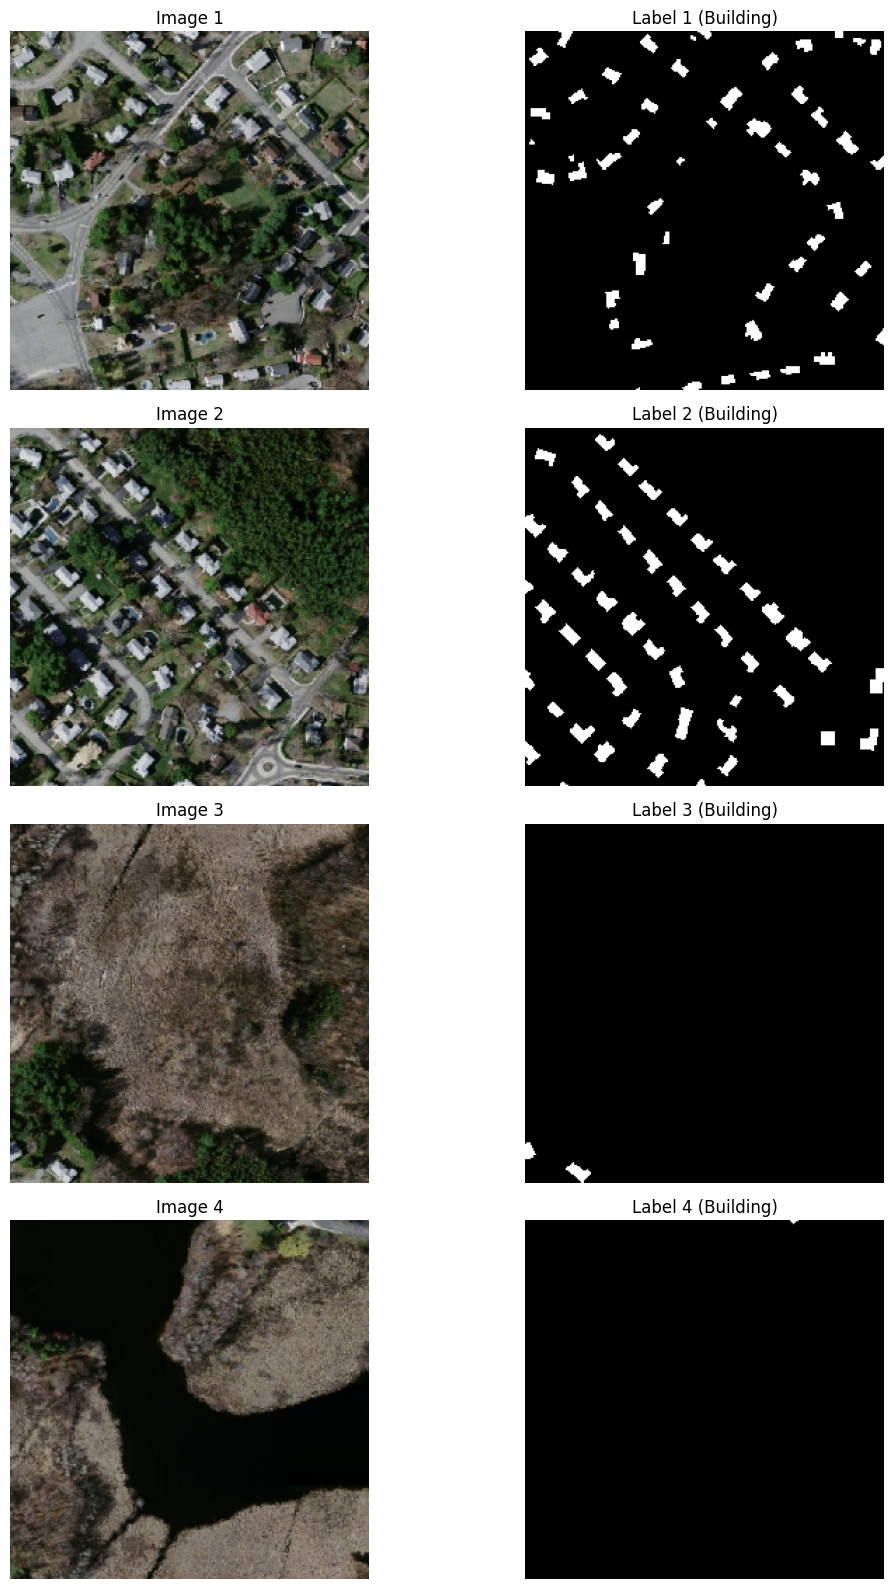

In [6]:
print(f"Image Shape: {images.shape}")  
print(f"Mask  Shape: {labels.shape}")  
print(f"Image Value Range: {images.min().item():.2f} to {images.max().item():.2f}")
print(f"Mask  Value Range: {labels.min().item():.2f} to {labels.max().item():.2f}")

# display image-label pairs
def visualize_pairs(images, labels, n=3):
    plt.figure(figsize=(12, n * 4))
    
    for i in range(n):
        # display image
        plt.subplot(n, 2, i*2 + 1)
        # permute from [C, H, W] to [H, W, C] for matplotlib
        plt.imshow(images[i].permute(1, 2, 0))
        plt.title(f"Image {i+1}")
        plt.axis('off')
        
        # display mask
        plt.subplot(n, 2, i*2 + 2)
        # Squeeze the channel dimension: [1, H, W] -> [H, W]
        plt.imshow(labels[i].squeeze(), cmap='gray')
        plt.title(f"Label {i+1} (Building)")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_pairs(images, labels, n=4)

Everything seems to be all right, however we noted that we have quite unbalanced dataset and only small portion of actual building, which is actually expected due to one image cpvering 300 sq.m area

3. Format the data as a `TensorDataset` and partition the observations into training (75%) and test (25%) samples. For each sample, create a `DataLoader` with a batch size suitable for your hardware (e.g. between 32 and 256).

<small>Note: Optionally, you can also include a validation sample by splitting the dataset into 70% training, 15% validation, and 15% test.</small>

In [7]:
# Create the full dataset
full_dataset = TensorDataset(images, labels)

# calculate split lengths
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  

# split
train_set, val_set, test_set = random_split(
    full_dataset, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

We decided to also use the validation dataset because we want to include early stopping criteria during the training

In [8]:
len(train_set), len(val_set), len(test_set)

(2342, 502, 503)

In [9]:
BATCH_SIZE = 64

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 37
Validation batches: 8
Test batches: 8


4. Using PyTorch, define a simplified U-Net model with the number of filters indicated in the figure above (i.e. 8, 16, 32, 64, 128, ...). Choose the appropriate activation functions for the hidden layers and the output layer.

<small>Note: Optionally, you can include batch normalisation and spatial dropout layers to improve the model’s optimisation and generalisation, respectively.</small>

In [10]:
# we deifne the double convolution operation separately to keep the code clean later
class DoubleConv(nn.Module):
    """(Conv2d -> BatchNorm -> ReLU -> Dropout) * 2"""
    def __init__(self, in_channels, out_channels, dropout_p=0.1):
        super().__init__()
        self.double_conv = nn.Sequential(
            # we use bias=False because BatchNorm cancels out the bias anyway

            # first convolution, we use padding=1 since our kernel is of side 3
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            # second convoluion, the same number of features
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            # we use spatial dropout instead of simple dropput because it's better to drop entire 2D feature maps rather than individual pixels
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        return self.double_conv(x)

# now we define the whole U-net architecture
class SimplifiedUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        
        # ENCODER - 4 layes, double conv per layer 
        self.down1 = DoubleConv(in_channels, 8)
        self.down2 = DoubleConv(8, 16)
        self.down3 = DoubleConv(16, 32)
        self.down4 = DoubleConv(32, 64)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # BOTTLENECK
        self.bottleneck = DoubleConv(64, 128, dropout_p=0.2)
        
        # DECODER - 4 layers again and we also include the skip connections to support using spatial infro from encoder layer
        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up4 = DoubleConv(128, 64)
        
        self.upconv3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.up3 = DoubleConv(64, 32)
        
        self.upconv2 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.up2 = DoubleConv(32, 16)
        
        self.upconv1 = nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2)
        self.up1 = DoubleConv(16, 8)
        
        # OUTPUT LAYER 
        self.out_conv = nn.Conv2d(8, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))
        
        # Bottleneck
        x5 = self.bottleneck(self.pool(x4))
        
        # Decoder
        d4 = self.upconv4(x5)
        d4 = torch.cat([x4, d4], dim=1) # Skip connection with encoder layer 4
        d4 = self.up4(d4)
        
        d3 = self.upconv3(d4)
        d3 = torch.cat([x3, d3], dim=1) # Skip connection with encoder layer 3
        d3 = self.up3(d3)
        
        d2 = self.upconv2(d3)
        d2 = torch.cat([x2, d2], dim=1) # Skip connection with encoder layer 2
        d2 = self.up2(d2)
        
        d1 = self.upconv1(d2)
        d1 = torch.cat([x1, d1], dim=1) # Skip connection with encoder layer 1
        d1 = self.up1(d1)
        
        # Output without activation because we already use the sigmoid in the loss
        logits = self.out_conv(d1)
        return logits

# print the model output shape
model = SimplifiedUNet()
dummy_input = torch.randn(64, 3, 256, 256) # [Batch, Channels, H, W]
output = model(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}") # Expected: [64, 1, 256, 256]

Input shape: torch.Size([64, 3, 256, 256])
Output shape: torch.Size([64, 1, 256, 256])


5. Initialise the model and print its architecture. Select an appropriate optimisation algorithm and loss function.

<small>Note: To address class imbalance — since building pixels represent only a small fraction of the total — you can weight the loss function or use loss functions specifically designed for imbalance, such as `torchvision.ops.sigmoid_focal_loss`.</small>


As recommended in the note above, we decided to use sigmoid_focal_loss. We have never worked with this loss fucntion before, and were interested to try it. It is a suitable choice because as we learned sigmoid_focal_loss is basically a modified version of binary cross‑entropy that down‑weights easy examples and focuses the model’s learning on the hard, misclassified, and minority‑class samples.

In [11]:
# intialize the network instance
device = torch.device("mps" if torch.mps.is_available() else "cpu")
model = SimplifiedUNet(in_channels=3, out_channels=1).to(device)

device

device(type='mps')

In [12]:
# print the architecture
print(model)

SimplifiedUNet(
  (down1): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Dropout2d(p=0.1, inplace=False)
    )
  )
  (down2): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, tr

In [15]:
# we will use Adam as optimizer with standard small learning rate
LEARNING_RATE = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# define the Loss Function

# alpha: Weighting factor for the rare class (buildings). 
# gamma: Focusing parameter. Higher values will strongly down-weight easy examples.

def calculate_loss(predictions, targets, alpha=0.75, gamma=2):
    """
    predictions: Raw logits from the model [B, 1, H, W]
    targets: Ground truth binary masks [B, 1, H, W] (Float32)
    """
    loss = sigmoid_focal_loss(
        predictions, 
        targets, 
        alpha=alpha,
        gamma=2.0,
        reduction='mean'
    )
    return loss

6. Write the PyTorch training routine and estimate the model parameters using the training sample.

Note: If you use a validation sample, implement a validation routine and apply early stopping to prevent overfitting.

In [16]:
# Hyperparameters for the training

# we will initialize the loss function hyperparameters to standard sensible values
alpha=0.75, # Higher alpha gives more weight to the buildings
gamma=2.0,  # Standard focusing parameter

EPOCHS = 50
PATIENCE = 5  # How many epochs to wait before stopping if no improvement

# initializing early stopping tracking variables
best_val_loss = float('inf')
epochs_no_improve = 0

print("Starting training...")

for epoch in range(EPOCHS):
    # TRAINING
    model.train() # Set model to training mode
    running_train_loss = 0.0
    
    for images, masks in train_loader:
        # move tensors to the device 
        images = images.to(device)
        masks = masks.to(device)
        
        # clear previous gradients
        optimizer.zero_grad()
        
        # forward pass
        predictions = model(images)
        
        # calculate loss
        loss = calculate_loss(predictions, masks)
        
        # backward pass (compute gradients)
        loss.backward()
        
        # update weights
        optimizer.step()
        
        # Accumulate loss (multiplying by batch size to get the true sum)
        running_train_loss += loss.item() * images.size(0)
        
    # calculate average training loss for the epoch
    epoch_train_loss = running_train_loss / len(train_set)
    
    # VALIDATION PHASE
    model.eval() # Set model to evaluation mode
    running_val_loss = 0.0
    
    # disable gradient calculation for validation to save memory and compute
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            predictions = model(images)
            loss = calculate_loss(predictions, masks)
            
            running_val_loss += loss.item() * images.size(0)
            
    # Calculate average validation loss for the epoch
    epoch_val_loss = running_val_loss / len(val_set)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    # EARLY STOPPING
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        
        # Save the model's best weights
        torch.save(model.state_dict(), 'best_unet_model.pth')
        print("  [*] Validation loss improved. Saved model checkpoint.")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs.")
            break

# Load the best weights back into the model before testing
model.load_state_dict(torch.load('best_unet_model.pth'))

Starting training...
Epoch 01/50 | Train Loss: 0.0470 | Val Loss: 0.0446
  [*] Validation loss improved. Saved model checkpoint.
Epoch 02/50 | Train Loss: 0.0358 | Val Loss: 0.0293
  [*] Validation loss improved. Saved model checkpoint.
Epoch 03/50 | Train Loss: 0.0298 | Val Loss: 0.0293
  [*] Validation loss improved. Saved model checkpoint.
Epoch 04/50 | Train Loss: 0.0276 | Val Loss: 0.0260
  [*] Validation loss improved. Saved model checkpoint.
Epoch 05/50 | Train Loss: 0.0259 | Val Loss: 0.0247
  [*] Validation loss improved. Saved model checkpoint.
Epoch 06/50 | Train Loss: 0.0248 | Val Loss: 0.0214
  [*] Validation loss improved. Saved model checkpoint.
Epoch 07/50 | Train Loss: 0.0240 | Val Loss: 0.0209
  [*] Validation loss improved. Saved model checkpoint.
Epoch 08/50 | Train Loss: 0.0237 | Val Loss: 0.0221
  [!] No improvement for 1 epoch(s).
Epoch 09/50 | Train Loss: 0.0227 | Val Loss: 0.0195
  [*] Validation loss improved. Saved model checkpoint.
Epoch 10/50 | Train Loss: 

<All keys matched successfully>

7. Compute the predicted probabilities for the test images.

In [17]:
# Set the model to evaluation mode
model.eval()

# Lists to store the batches
test_probabilities = []
test_ground_truths = []

# disable gradient calculation
with torch.no_grad():
    for images, masks in test_loader:
        # move inputs to the correct device (GPU/CPU)
        images = images.to(device)
        
        # forward pass: get raw logits from the model
        logits = model(images)
        
        # convert logits to probabilities
        probs = torch.sigmoid(logits)
        
        # we also store the ground truth masks for future evaluation
        test_probabilities.append(probs.cpu())
        test_ground_truths.append(masks)

# concatenate all batches into a single large tensor
all_test_probs = torch.cat(test_probabilities, dim=0)
all_test_masks = torch.cat(test_ground_truths, dim=0)

# double check the shapes
print(f"Shape of test probabilities: {all_test_probs.shape}") 
print(f"Shape of ground truth masks: {all_test_masks.shape}")

Shape of test probabilities: torch.Size([503, 1, 256, 256])
Shape of ground truth masks: torch.Size([503, 1, 256, 256])


8. Assess the model's generalisation performance by computing the confusion matrix, along with precision and recall metrics on the test sample. Comment on the results.

Precision: 0.6201
Recall:    0.8768


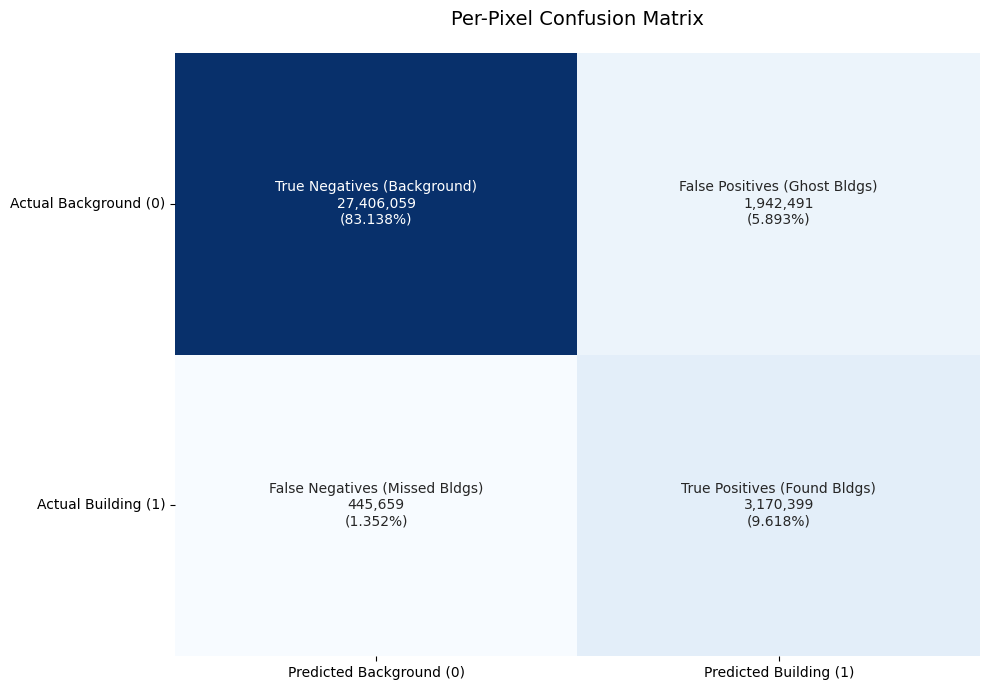

In [18]:
# Since we don't have guidelines for the threshold, we will assume 0.5 by default
# Convert probabilities to predictions
THRESHOLD = 0.5
predicted_masks = (all_test_probs > THRESHOLD).float()

# flatten the tensors to treat every pixel as an individual prediction
preds_flat = predicted_masks.view(-1)
truths_flat = all_test_masks.view(-1) # all_test_masks is from the previous step

# calculate Confusion Matrix components
TP = torch.sum((preds_flat == 1) & (truths_flat == 1)).item()
TN = torch.sum((preds_flat == 0) & (truths_flat == 0)).item()
FP = torch.sum((preds_flat == 1) & (truths_flat == 0)).item()
FN = torch.sum((preds_flat == 0) & (truths_flat == 1)).item()

# compute Precision and Recall
precision = TP / (TP + FP + 1e-7)
recall = TP / (TP + FN + 1e-7)

# display the results
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

# calculate the total number of pixels evaluated
total_pixels = TP + TN + FP + FN

# calculate percentages for each quadrant
tp_pct = (TP / total_pixels) * 100
tn_pct = (TN / total_pixels) * 100
fp_pct = (FP / total_pixels) * 100
fn_pct = (FN / total_pixels) * 100

# format the data for Seaborn
matrix_data = np.array([[TN, FP], [FN, TP]])

# annotations 
annotations = np.array([
    [f"True Negatives (Background)\n{TN:,}\n({tn_pct:.3f}%)", f"False Positives (Ghost Bldgs)\n{FP:,}\n({fp_pct:.3f}%)"],
    [f"False Negatives (Missed Bldgs)\n{FN:,}\n({fn_pct:.3f}%)", f"True Positives (Found Bldgs)\n{TP:,}\n({tp_pct:.3f}%)"]
])

# plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    matrix_data, 
    annot=annotations, 
    fmt="", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["Predicted Background (0)", "Predicted Building (1)"],
    yticklabels=["Actual Background (0)", "Actual Building (1)"]
)

plt.title("Per-Pixel Confusion Matrix", fontsize=14, pad=20)
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

The model achieves a precision of 0.6201, meaning that when it predicts a building, it is correct roughly two‑thirds of the time. This aligns with the noticeable number of false positives in the matrix. At the same time, the recall of 0.8768 shows that the model successfully captured most of the actual building pixels, missing only a smaller fraction of them. So the model is relatively good at finding buildings (high recall) but still struggles with being certain about them (moderate precision), which is probably because the minority class is harder to distinguish and under‑represented in training.

This confusion matrix highlights the strong class imbalance in the dataset and how it affects model performance. The model correctly identifies the vast majority of background pixels (true negatives), which dominate the dataset, but this also means accuracy alone is misleading. The more meaningful signals are in the bottom two cells: the model successfully detects a substantial portion of building pixels (true positives), yet still misses a noticeable number of them (false negatives). The false positives—background pixels incorrectly labeled as buildings—show that the model is somewhat over-confident in predicting the minority class, which is no surprise as we overweighted the minority class. Overall, focal loss helped us shift learning toward the relatively rare building pixels that matter most.

Now we want to analyze these statistics on image level, rather than pixel

 Image-Level F1 Statistics 
Average F1:     0.703
25th Percentile: 0.666 (Bottom 25% of images score below this)
Median F1:      0.720
75th Percentile: 0.774 (Top 25% of images score above this)


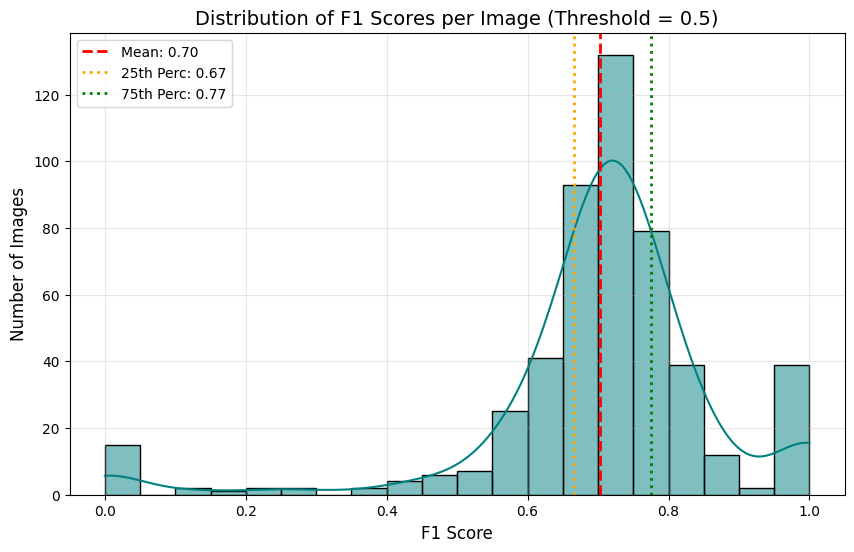

In [21]:
image_f1_scores = []

# Ensure the tensors are in [N, 1, H, W] format
for i in range(len(all_test_probs)):
    # Binarize prediction for this specific image and flatten
    pred_img = (all_test_probs[i] > THRESHOLD).float().view(-1).numpy()
    true_img = all_test_masks[i].view(-1).numpy()
    
    # Check for the "Empty Field" edge case
    if true_img.sum() == 0 and pred_img.sum() == 0:
        score = 1.0  # Perfect prediction of empty background
    else:
        # zero_division=0 ensures we don't get warnings if it predicts buildings incorrectly on an empty field
        score = f1_score(true_img, pred_img, zero_division=0)
        
    image_f1_scores.append(score)

image_f1_scores = np.array(image_f1_scores)

# Calculate Statistics
f1_mean = np.mean(image_f1_scores)
f1_p25 = np.percentile(image_f1_scores, 25)
f1_p50 = np.median(image_f1_scores)
f1_p75 = np.percentile(image_f1_scores, 75)

print(" Image-Level F1 Statistics ")
print(f"Average F1:     {f1_mean:.3f}")
print(f"25th Percentile: {f1_p25:.3f} (Bottom 25% of images score below this)")
print(f"Median F1:      {f1_p50:.3f}")
print(f"75th Percentile: {f1_p75:.3f} (Top 25% of images score above this)")

# Plotting the Distribution
plt.figure(figsize=(10, 6))
sns.histplot(image_f1_scores, bins=20, kde=True, color='teal', edgecolor='black')

# Add vertical lines for the stats
plt.axvline(f1_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {f1_mean:.2f}')
plt.axvline(f1_p25, color='orange', linestyle='dotted', linewidth=2, label=f'25th Perc: {f1_p25:.2f}')
plt.axvline(f1_p75, color='green', linestyle='dotted', linewidth=2, label=f'75th Perc: {f1_p75:.2f}')

plt.title(f'Distribution of F1 Scores per Image (Threshold = {THRESHOLD})', fontsize=14)
plt.xlabel('F1 Score', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

These statistics show that the model performs consistently well across the dataset, with an average F1 of 0.713 indicating solid overall balance between precision and recall. The median F1 of 0.720 being slightly higher than the mean suggests a mild skew caused by a subset of harder images pulling the average down. The 25th percentile at 0.666 marks the lower‑performing quarter of images—likely those with challenging conditions such as shadows, or small buildings. Meanwhile, the 75th percentile at 0.774 shows that the top quarter of images achieve strong, reliable segmentation quality. Overall, the distribution reflects a stable model that performs well on most scenes, but there still is a room for improvement.

9. Implement a function to visualise true positives, true negatives, false positives, and false negatives as overlays on the input image.

In [22]:
def visualize_evaluation_overlay(image_tensor, true_mask_tensor, pred_mask_tensor):
    """
    Overlays TP (Green), TN (Grey), FP (Yellow), and FN (Red) on the original image.
    
    Args:
        image_tensor: [3, H, W] PyTorch tensor (values 0.0 to 1.0)
        true_mask_tensor: [1, H, W] or [H, W] PyTorch tensor (binary 0 or 1)
        pred_mask_tensor: [1, H, W] or [H, W] PyTorch tensor (binary 0 or 1)
    """
    # convert PyTorch tensors to NumPy arrays and fix dimensions
    img_np = image_tensor.cpu().permute(1, 2, 0).numpy()
    true_np = true_mask_tensor.cpu().squeeze().numpy()
    pred_np = pred_mask_tensor.cpu().squeeze().numpy()

    # calculate the four quadrants 
    TP = (pred_np == 1) & (true_np == 1)
    TN = (pred_np == 0) & (true_np == 0)
    FP = (pred_np == 1) & (true_np == 0)
    FN = (pred_np == 0) & (true_np == 1)

    # initialize an empty RGBA overlay [H, W, 4]
    H, W = true_np.shape
    overlay = np.zeros((H, W, 4), dtype=np.float32)

    # assign Colors (R, G, B, Alpha)
    # Green for True Positives
    overlay[TP] = [0.0, 1.0, 0.0, 0.5] 
    
    # Grey for True Negatives (very transparent so image is clear)
    overlay[TN] = [0.5, 0.5, 0.5, 0.15] 
    
    # Yellow for False Positives (Model predicted building, but there isn't one)
    overlay[FP] = [1.0, 1.0, 0.0, 0.6] 
    
    # Red for False Negatives (Model missed an actual building)
    overlay[FN] = [1.0, 0.0, 0.0, 0.6] 

    # plotting
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Show base image
    ax.imshow(img_np)
    
    # Show overlay
    ax.imshow(overlay)
    
    # legend
    legend_elements = [
        mpatches.Patch(color=(0.0, 1.0, 0.0, 0.5), label='True Positive (Correct Building)'),
        mpatches.Patch(color=(0.5, 0.5, 0.5, 0.3), label='True Negative (Correct Background)'),
        mpatches.Patch(color=(1.0, 1.0, 0.0, 0.6), label='False Positive (Ghost Building)'),
        mpatches.Patch(color=(1.0, 0.0, 0.0, 0.6), label='False Negative (Missed Building)')
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    ax.set_title("Segmentation Evaluation Overlay", fontsize=14, pad=15)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Now we visualize one sample

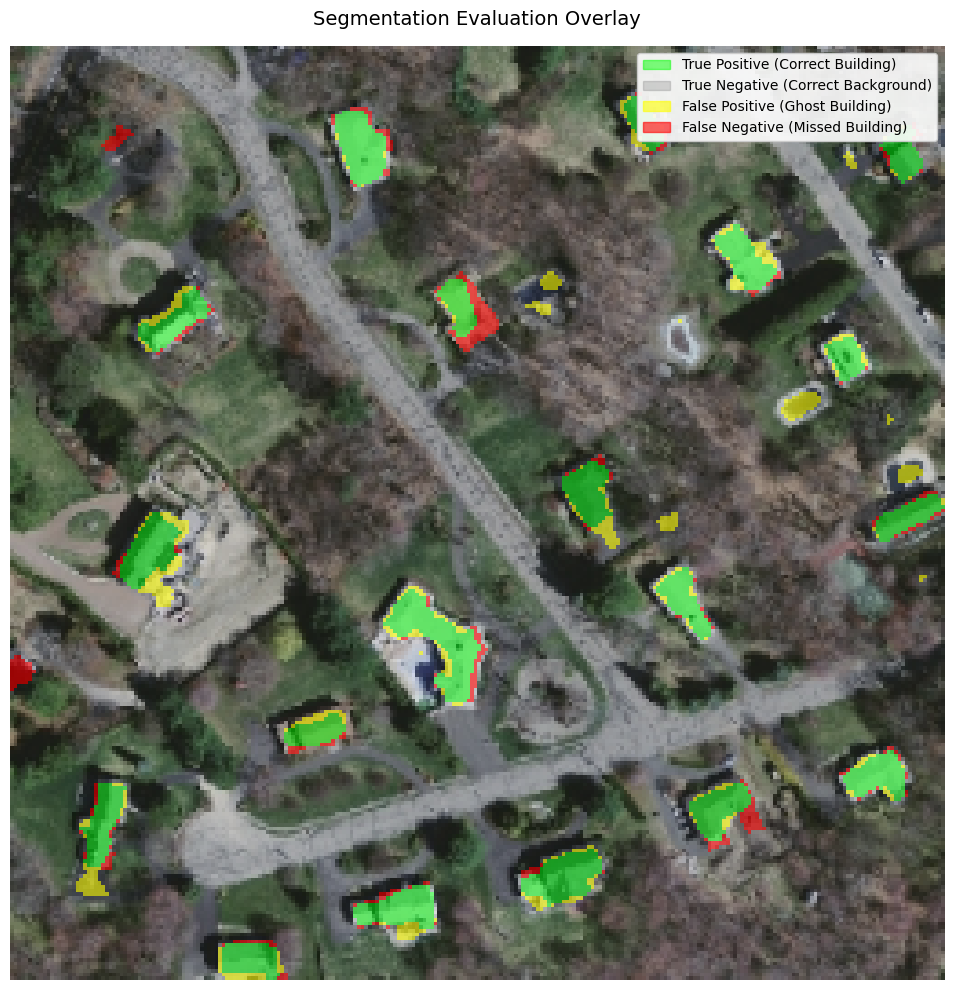

In [23]:
# grab one batch of test data
model.eval()
images, true_masks = next(iter(test_loader))
images = images.to(device)

# get predictions for the batch
with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    pred_masks = (probs > 0.58).float() # Binarize

# select an image index to view, let's do 0
idx = 0

# call the visualization function
visualize_evaluation_overlay(
    image_tensor=images[idx], 
    true_mask_tensor=true_masks[idx], 
    pred_mask_tensor=pred_masks[idx]
)

The green regions show where buildings are correctly detected, while the yellow background confirms that most non‑building areas are classified accurately. The red patches highlight missed buildings, revealing where the model struggles—often along roof edges, small structures, or visually ambiguous areas. The grayish‑yellow false positives show places where the model “hallucinates” buildings. We can say that the model basically identified the most important bits, it struggles with edges, which actually can be improved with the arcitecture.

This was a random sample. We decided to visualize the wors F1 score in the test set next

F1 Score: 0.0000


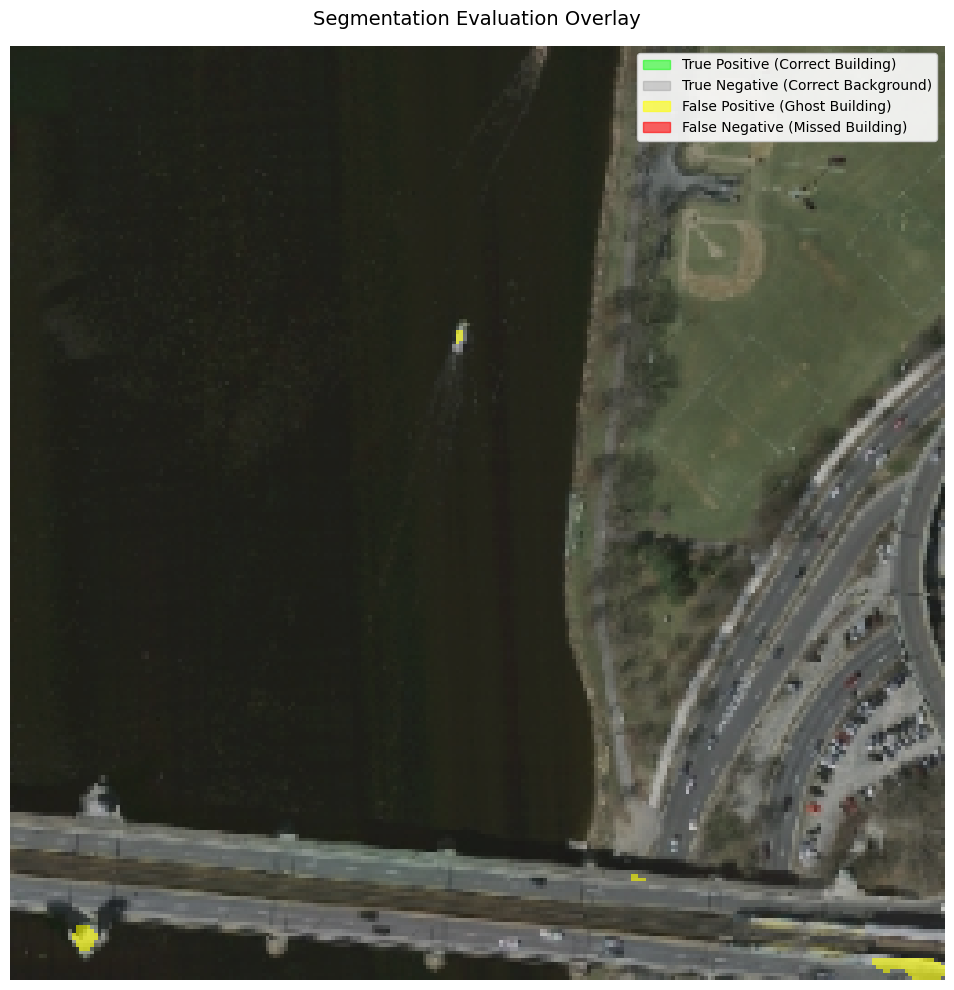

In [24]:
# find the index of the absolute lowest F1 score
lowest_idx = np.argmin(image_f1_scores)
lowest_score = image_f1_scores[lowest_idx]

print(f"F1 Score: {lowest_score:.4f}")

# retrieve the original image and true mask directly from the test dataset
worst_image, worst_true_mask = test_set[lowest_idx]

# retrieve the corresponding probability from our saved predictions
worst_prob = all_test_probs[lowest_idx]

# convert the probability to a binary mask using our threshold
worst_pred_mask = (worst_prob > THRESHOLD).float()

# visualize using the function we just built
visualize_evaluation_overlay(
    image_tensor=worst_image,
    true_mask_tensor=worst_true_mask,
    pred_mask_tensor=worst_pred_mask
)

Well, this image has F1 score of 0, because it identified Ghost building 2 times, 1 I guess is a part of the bridge and the other one some structure on the highway. I can't really judge the model over this, improving tha architecture, maybe giving the model ability to learn more abstract features would help the model to learn the bridge pattern. But for the very basic model that we built, this is a decent mistake I would say. 

10. Assuming that we give equal importance to reducing false positives and false negatives, use a decision probability threshold that strikes the best balance between these two quantities.

We will first plot ROC curve, also the precision-recall curve, because ROC might be misleading with imbalanced class like in our case, and finally the metrics over different thresholds

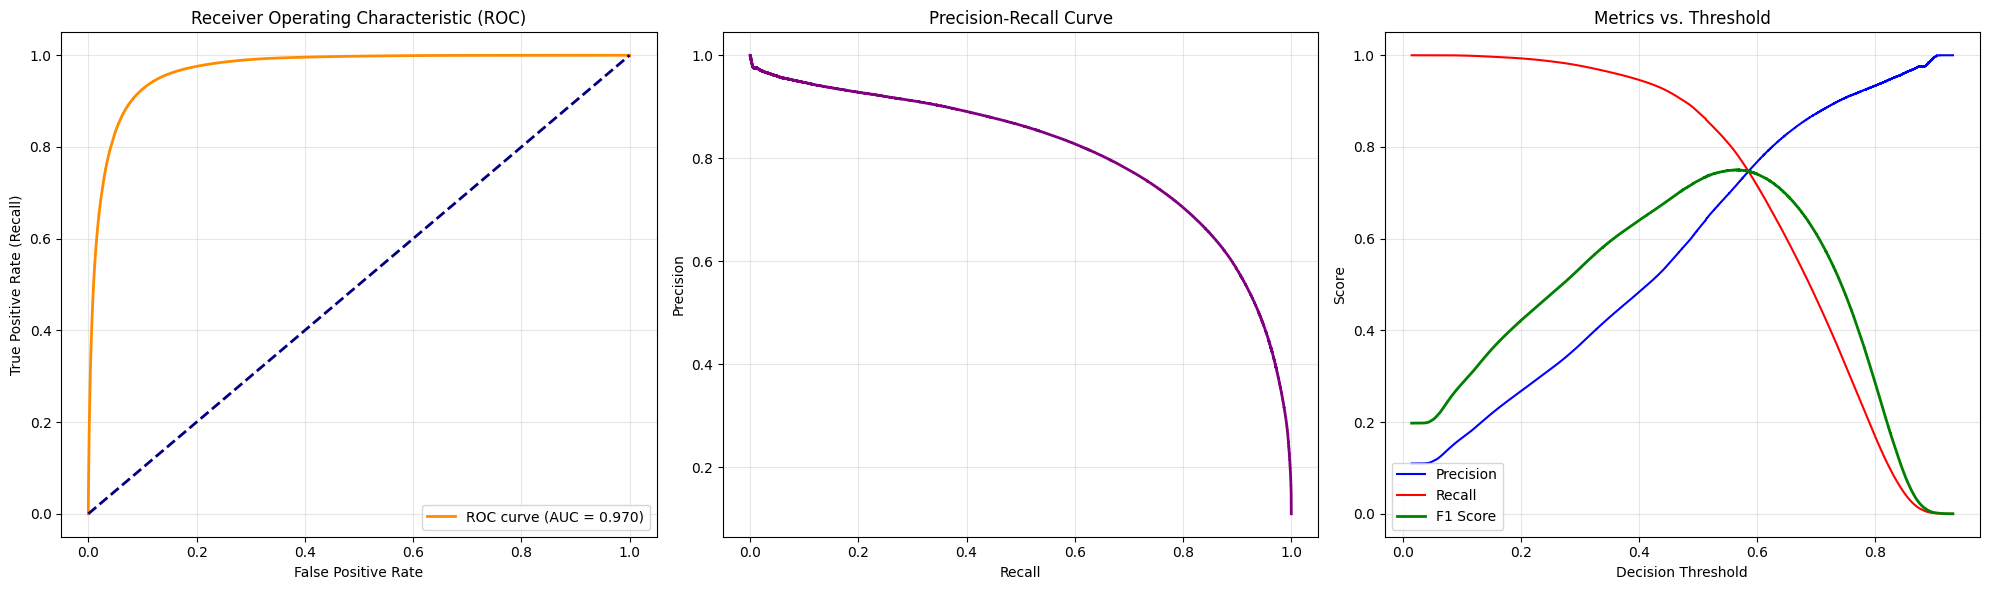

Optimal Threshold (Highest F1): 0.567
Max Global F1 Score: 0.750


In [25]:
# flatten tensors and convert to NumPy 
y_true = all_test_masks.view(-1).numpy()
y_scores = all_test_probs.view(-1).numpy()

# calculate ROC and PR data
fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

precisions, recalls, pr_thresholds = precision_recall_curve(y_true, y_scores)

# Calculate F1 scores across all thresholds
# Note: precision_recall_curve returns one extra value for precisions and recalls (at threshold=1.0), so we slice [:-1] to match the length of pr_thresholds.
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-7)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plot A: ROC Curve
axs[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axs[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axs[0].set_xlabel('False Positive Rate')
axs[0].set_ylabel('True Positive Rate (Recall)')
axs[0].set_title('Receiver Operating Characteristic (ROC)')
axs[0].legend(loc="lower right")
axs[0].grid(True, alpha=0.3)

# Plot B: Precision-Recall Curve
axs[1].plot(recalls, precisions, color='purple', lw=2)
axs[1].set_xlabel('Recall')
axs[1].set_ylabel('Precision')
axs[1].set_title('Precision-Recall Curve')
axs[1].grid(True, alpha=0.3)

# Plot C: Metrics vs. Thresholds
axs[2].plot(pr_thresholds, precisions[:-1], color='blue', label='Precision')
axs[2].plot(pr_thresholds, recalls[:-1], color='red', label='Recall')
axs[2].plot(pr_thresholds, f1_scores, color='green', label='F1 Score', lw=2)
axs[2].set_xlabel('Decision Threshold')
axs[2].set_ylabel('Score')
axs[2].set_title('Metrics vs. Threshold')
axs[2].legend(loc="lower left")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find and print the optimal threshold based on F1 Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = pr_thresholds[optimal_idx]
print(f"Optimal Threshold (Highest F1): {optimal_threshold:.3f}")
print(f"Max Global F1 Score: {f1_scores[optimal_idx]:.3f}")

We identified the optimal decision threshold to be 0.567. This represents the point where the model achieves the best balance between false positives and false negatives when evaluated across all pixels. At this threshold, the model reaches a maximum global F1 score of 0.750, indicating a stronger harmonic balance between precision and recall than at the default 0.5 cutoff. This suggests that slightly raising the threshold makes the model more selective in predicting buildings, reducing false positives without sacrificing too many true positives. Overall, we believe F1 is the correct metric to choose the threshold when we equally value the precision and recall.